In [70]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
import ipywidgets as widgets

# Introduction to Quantum Walks

## What are Quantum Walks?

Quantum walks are the quantum equivalent of the classical random walk. The main idea behind random walks is that there is a walker living in some space, for example in a line, 2D, 3D grid, or in a graph, and move in its environment by randomly picking where to go. For example in a 2D grid the walker will either walk left, right, up or down, and in a graph it will randomly choose which adjacent edges to traverse [2][5].

Quantum walks contain a variety of different use cases, some of which include for example algorithm-design (such as finding collisions or database searching) and also for implementing universal quantum computing [1][2].

The topic revolving around Quantum Walks is quite vast. There exist both Discrete-Time Quantum Walks (DTQW) and Continuous-Time Quantum Walks (CTQW), which refer to how the walker's state evolves over time (either in discrete steps or in continuous evolution). Even DTQWs can have subgroups such as coin-based and non-coin-based algorithms. So to reduce the scope for this project, we shall only focus specifically on coin-based DTQW algorithms, their theory, and implementation [1].

## Coin-Based Discrete-Time Quantum Walks

In the coin-based DTQWs, we have two registers of qubits which acts as our walker.

$$ |x\rangle|c\rangle  $$

Where $|x\rangle$ is the current position our walker is in and $|c\rangle$ is the coin state which holds the direction of the walker.

The evolution of the coin-based DTQW happens by applying two operators: the coin operator (C) and shift operator (S). The coin operator will choose the direction to which the walker will go, and only transform the coin register $|c\rangle$'s state (so the operation is $ I_S ⊗ C$). The shift operator will act on both $|x\rangle$ and $|c\rangle$ to shift the walker to another position, using whatever the state of $|c\rangle$ is to determine where the walker might be now. For example, if we were walking on a line where going left or right is equally probable (so $I_S ⊗ C|x\rangle|c\rangle = \frac{1}{\sqrt{2}}|x\rangle|L\rangle + |R\rangle$), (i.e the coin is a Hadamard gate), then after applying the shift operator, we can either get: $$ S|x\rangle|L\rangle = |x - 1\rangle|L\rangle, S|x\rangle|L\rangle = |x + 1\rangle|R\rangle $$

We can combine the coin operator and shift operator and write it as a single unitary: $$ U = S(C⊗I_S) $$
Each application of unitary $U$ will be a single step for the walker.

There exist different choices for coin operators, and the two most common are the Hadamard coin, and the Grover coin.
The Hadamard gate is implemented as follows: $$ C = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} $$ 

And Grover coin is: $$ C = \begin{bmatrix} \frac{2}{N} - 1 & \frac{2}{N} & \dots & \frac{2}{N} \\ \frac{2}{N} & \frac{2}{N} - 1 & \dots & \frac{2}{N} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{2}{N} & \frac{2}{N} & \dots & \frac{2}{N} - 1  \end{bmatrix} $$

Where N is the dimension. Each application of the Grover coin is a single iteration of Grover's search algorithm [1][3].

Let us show an example of how to implement a Quantum Walk traversing a 1D environment (which in reality is a walk in a circle of points since the last and first positions are connected) [4]. The implementation from [2] is shown in the code-snippet below:

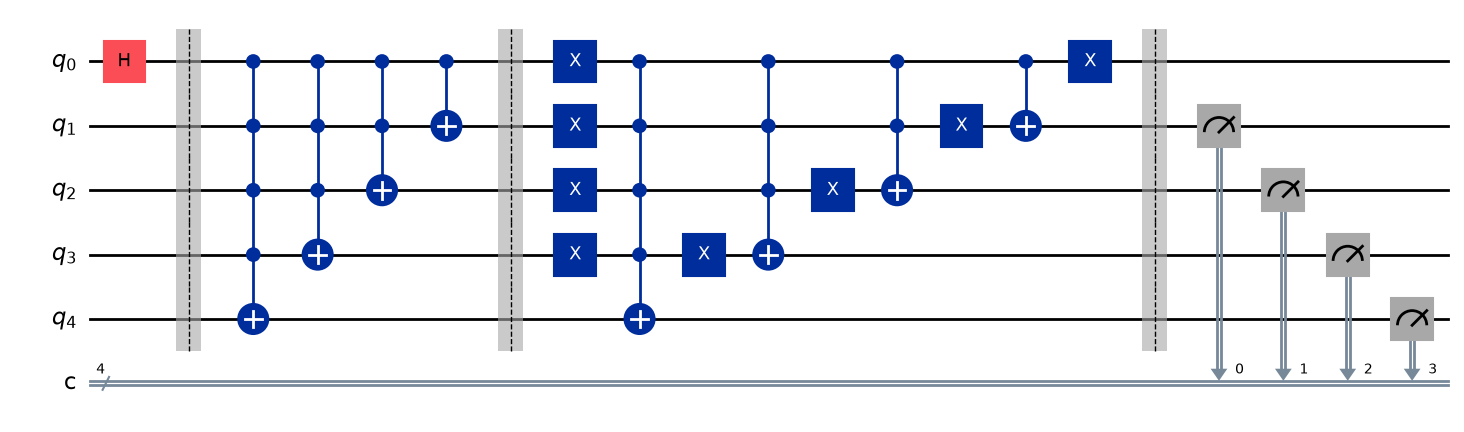

In [71]:

def oned_incr_operator(q_cir, pos_register):
    
    # Creates an increment operator for pos_register number of qubits
    
    num_of_controls = pos_register
    target = pos_register
    
    for i in range(0, pos_register):        
        controls = []
        
        for j in range(0, num_of_controls):
            controls.append(j)

        q_cir.mcx(control_qubits=controls,target_qubit=target)
        num_of_controls = num_of_controls - 1
        target = target - 1

def oned_decr_operator(q_cir, pos_register):
    
    # Creates an decrement operator for pos_register number of qubits

    num_of_controls = pos_register
    target = pos_register
    
    for i in range(0, pos_register):
        q_cir.x(i)
    
    for j in range(0, pos_register):        
        anti_controls = []
        
        for k in range(0, num_of_controls):
            anti_controls.append(k)

        q_cir.mcx(control_qubits=anti_controls,target_qubit=target)
        q_cir.x(target - 1)
        num_of_controls = num_of_controls - 1
        target = target - 1

def oned_steps(num_steps, q_cir, pos_register):
    
    # Runs a single step in the circuit

    for i in range(0, num_steps):
        q_cir.h(0)
        #q_cir.s(0)
        q_cir.barrier()
        oned_incr_operator(q_cir, pos_register)
        q_cir.barrier()
        oned_decr_operator(q_cir, pos_register)    

def oned_create_circuit(num_steps, pos_register):
    
    # Creates our quantum circuit
    
    q_cir = QuantumCircuit(1 + pos_register, pos_register)
    
    oned_steps(num_steps, q_cir, pos_register)
    
    q_cir.barrier()
    
    for i in range(0, pos_register):
        q_cir.measure(i + 1, i)
                
    return q_cir

def oned_run_circuit(q_cir, shots):

    # Runs a given circuit some shots number of times

    sampler = StatevectorSampler()
    result = sampler.run([q_cir], shots=shots).result()
    return result[0].data.c.get_counts()

position_register = 4
number_of_steps = 1
qc = oned_create_circuit(number_of_steps, position_register)

qc.draw(output="mpl")


The image above depicts a single iteration of the 1D quantum walk with five qubits. Qubit 0 represents the coin register and qubits 1-4 determine the position of the walker in a circle of size $2^4$. The algorithm works by having the coin state be either 0 or 1 depending on the result from the Hadamard coin, and this result will be used to either shift left or shift right. The implementation performs the shift by either invoking the increment or decrement operator (which are the series of gates separated by boundaries). The increment and decrement operators are both staircases of multi-qubit X gates going from the most significant to least significant qubit (and then fully controlled by the coin state). The decrement operator is different however as it contains single-qubit X gates around the control qubits to turn them into anti-control qubits. Once we have run circuit, we can then measure the position register and find out what our final state was [2].

An interesting effect exists regarding the probability distribution of DTQW as we let it evolve over time. In a classical random walks we expect a probability distribution to be gaussian, and for each additional step added, the variance of that distribution increases. This is not the case for the quantum walks. The distribution will contain a bias to one of the sides of the distribution [1][2][3] as we increase the number of steps. In the next code cell, you'll see a bar plot containing the results for a 1D quantum walk with a decidable number of qubits for the position register and steps to take.

In [72]:
def oned_plot_results(steps = 0, qubits = 1):
    
    qc = oned_create_circuit(steps, qubits)
    counts = oned_run_circuit(qc, shots=2048)
    
    states = []
    state_counts = []
    
    for i in range(0, 2**qubits):
        states.append(i)
        next_state_count = 0
        
        for j in counts:
            if i == int(j, 2):
                next_state_count = counts[j]

        state_counts.append(next_state_count)
    
    # To make sure that it is easier to see the distribution, I take the second half from states and 
    # state_counts and put them in front so the 0th position in both is centered.
    # I also convert each entry in states to strings so plt does not automatically put 0 to the left side of the plot
    
    first_half_states = states[:len(states)//2]
    second_half_states = states[len(states)//2:]

    first_half_states_count = state_counts[:len(states)//2]
    second_half_states_count = state_counts[len(states)//2:]
    
    centered_states = second_half_states + first_half_states
    centered_states = list(map(str, centered_states))
    centered_states_count = second_half_states_count + first_half_states_count

    #print(centered_states)
    #print(centered_states_count)
        
    plt.figure(figsize=(15, 3))
    plt.bar(centered_states, centered_states_count)




In [73]:
widgets.interact(oned_plot_results,steps=(0,50,1), qubits=(1,8,1))

interactive(children=(IntSlider(value=0, description='steps', max=50), IntSlider(value=1, description='qubits'…

<function __main__.oned_plot_results(steps=0, qubits=1)>

You can see the effect of this bias for yourself by playing around with the size of the walking environment (qubits) and steps. For example if you put the slider to 4 qubits and gradually move the steps from 0 to 12 you'll see the state containing the most shots will move gradually to the left. You can also see the effect clearly if you put the qubits to 6-8 and the slider to 50. Do also notice that we split the possible states in half and move the second half in front so 0 is more or less in the middle. This bias is particularly interesting, as it is used to solve problems which typically are unsolvable for classical random walks [2].

If one does wish to turn the probability distribution to something closer to a gaussian distribution, you can instead of evolving the coin state to $$\frac{1}{\sqrt{2}}|x\rangle|L\rangle + |R\rangle$$ We can use a gate that produces: $$\frac{1}{\sqrt{2}}|x\rangle|L\rangle + i|R\rangle$$ This should be possible by using the unitary: $$ U = H * S $$ Here S meaning the phase gate $S = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix}$ and not the shift operator [3].
The code below is nearly identical to the code for the 1D quantum walk algorithm from before, but now we add an S gate in front of the Hadamard coin. Do note that even though we should see a more gaussian distribution, this implementation here was not able to reproduce that result. Regardless, you are still able to take a look for yourself.

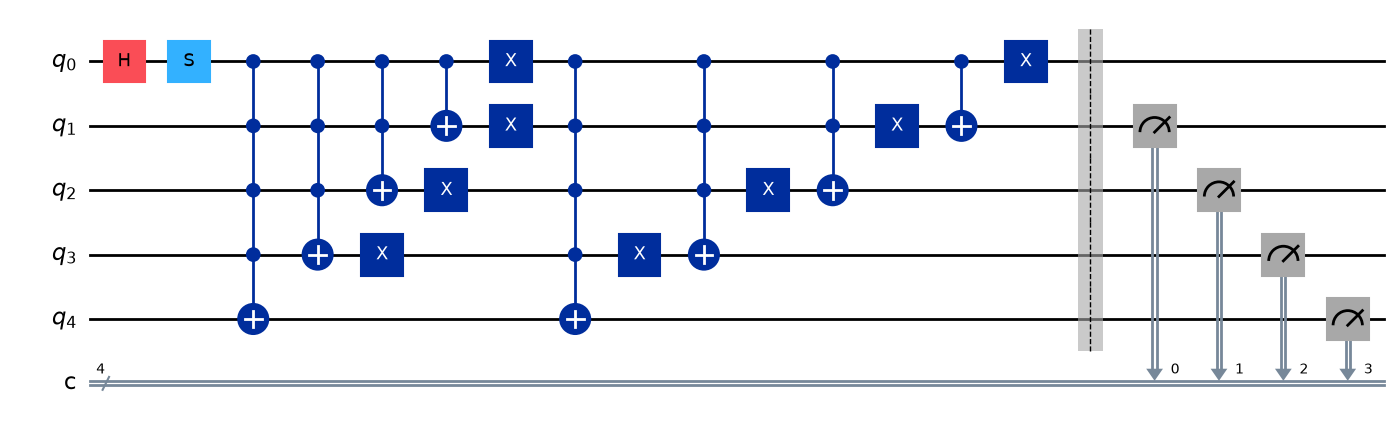

In [74]:
# Same code but we replace add S in front of H in the circuit.

def even_oned_steps(num_steps, q_cir, pos_register):
    
    # Runs a single step in the circuit

    for i in range(0, num_steps):
        q_cir.h(0)
        q_cir.s(0)
        oned_incr_operator(q_cir, pos_register)
        oned_decr_operator(q_cir, pos_register)    


def even_oned_create_circuit(num_steps, pos_register):
    
    # Creates our quantum circuit
    
    q_cir = QuantumCircuit(1 + pos_register, pos_register)
    
    even_oned_steps(num_steps, q_cir, pos_register)
    
    q_cir.barrier()
    for i in range(0, pos_register):
        q_cir.measure(i + 1, i)
                
    return q_cir

def even_oned_plot_results(steps = 0, qubits = 1):
    
    qc = even_oned_create_circuit(steps, qubits)
    counts = oned_run_circuit(qc, shots=2048)
    
    states = []
    state_counts = []
    
    for i in range(0, 2**qubits):
        states.append(i)
        next_state_count = 0
        
        for j in counts:
            if i == int(j, 2):
                next_state_count = counts[j]

        state_counts.append(next_state_count)
    
    # To make sure that it is easier to see the distribution, I take the second half from states and 
    # state_counts and put them in front so the 0th position in both is centered.
    # I also convert each entry in states to strings so plt does not automatically put 0 to the left side of the plot
    
    first_half_states = states[:len(states)//2]
    second_half_states = states[len(states)//2:]

    first_half_states_count = state_counts[:len(states)//2]
    second_half_states_count = state_counts[len(states)//2:]
    
    centered_states = second_half_states + first_half_states
    centered_states = list(map(str, centered_states))
    centered_states_count = second_half_states_count + first_half_states_count

    print(centered_states)
    print(centered_states_count)
        
    plt.figure(figsize=(15, 3))
    plt.bar(centered_states, centered_states_count)

qc = even_oned_create_circuit(1, 4)
qc.draw(output="mpl")


In [75]:
widgets.interact(even_oned_plot_results,steps=(0,50,1), qubits=(1,8,1))


interactive(children=(IntSlider(value=0, description='steps', max=50), IntSlider(value=1, description='qubits'…

<function __main__.even_oned_plot_results(steps=0, qubits=1)>

We are capable of expanding the 1D quantum walk quite easily to a 2D walk with the elements used for the 1D algorithm. The next code cell below is from [4]:

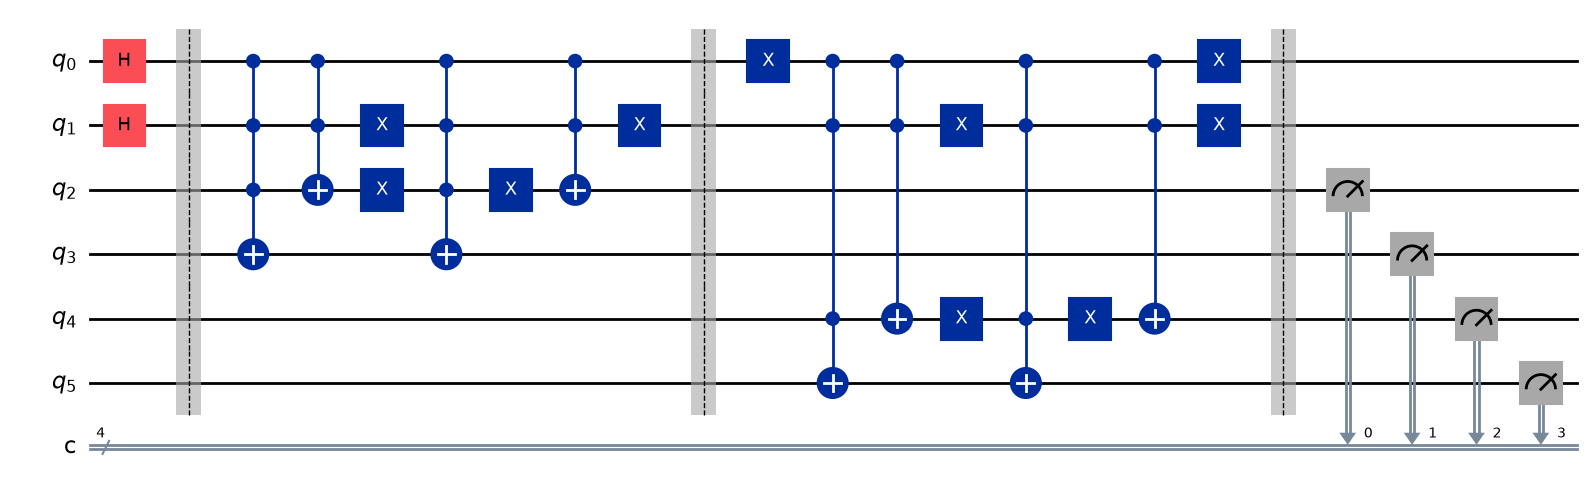

In [76]:
# Quantum Walk on 2D graph

def twod_incr_operator(q_cir, register):
    
    num_of_controls = len(register) - 1
    target = max(register)
    
    for i in range(0, len(register)):
        controls = [0,1]
        
        for j in range(0, num_of_controls):
            controls.append(register[j])
        q_cir.mcx(control_qubits=controls,target_qubit=target)
        num_of_controls = num_of_controls - 1
        target = target - 1
    
def twod_decr_operator(q_cir, register):
    
    num_of_controls = len(register) - 1
    target = max(register)
    
    for i in range(0, len(register) - 1):
        q_cir.x(register[i])
    
    for j in range(0, len(register)):
        controls = [0,1]
        
        for k in range(0, num_of_controls):
            controls.append(register[k])

        #print("decr controls: ", controls)
        #print("decr targets: ", target)

        q_cir.mcx(control_qubits=controls,target_qubit=target)
        if target - 1 > min(register) - 1: # This tiny if statement is simply there to prevent the last X gate to be made. This is obviously not the best way to handle it but it'll work for now.
            q_cir.x(target - 1)
        num_of_controls = num_of_controls - 1
        target = target - 1

def twod_steps(q_cir, num_steps):
    
    # Runs a single step in the circuit

    full_register = []

    for i in range(2, q_cir.num_qubits):
        full_register.append(i)

    first_register = full_register[:len(full_register)//2]    
    second_register = full_register[len(full_register)//2:]
    
    #print("First Register: ", first_register)
    #print("Second Register: ", second_register)
    
    for i in range(0, num_steps):
        q_cir.h(0)
        q_cir.h(1)
        q_cir.barrier()
        twod_incr_operator(q_cir, first_register)
        q_cir.x(1)
        twod_decr_operator(q_cir, first_register)
        q_cir.x(1)
        q_cir.barrier()
        q_cir.x(0)
        twod_incr_operator(q_cir, second_register)
        q_cir.x(1)
        twod_decr_operator(q_cir, second_register)
        q_cir.x(1)
        q_cir.x(0)


def twod_create_circuit(num_steps, position_register_qubits):
    
    # Creates our quantum circuit
    
    q_cir = QuantumCircuit(2 + 2**position_register_qubits, 2**position_register_qubits)
    
    twod_steps(q_cir, num_steps)
    
    q_cir.barrier()
    
    full_register = []

    for i in range(2, q_cir.num_qubits):
        full_register.append(i)

    for j in range(0, len(full_register)):
        q_cir.measure(full_register[j],j)
    #for i in range(0, q_cir.num_qubits):
    #    q_cir.measure(i, i)
                
    return q_cir

def twod_run_circuit(q_cir, shots):

    # Runs a given circuit some shots number of times

    sampler = StatevectorSampler()
    result = sampler.run([q_cir], shots=shots).result()
    return result[0].data.c.get_counts()

position_register_qubits = 2
number_of_steps = 1
qc = twod_create_circuit(number_of_steps, position_register_qubits)

qc.draw(output="mpl")

#counts = twod_run_circuit(qc, shots=1024)
#print("Counts: ", counts)
#twod_run_circuit(qc, shots=2048)

#Plot
    



The circuit above showcases a 2D quantum walk with 6 qubits. As we can see, the implementation contains similarities to the previous 1D quantum walk, however we now have two qubits for the coin state and two registers representing the x (qubits 2, 3) and y (qubits 4, 5) coordinates of the walker. We have a pair of increment/decrement operators on both the first and second registers, however we create a distinction on whether to walk up or down with the use of our additional qubit in the coin state. Qubit 1 will do the same as it did in the 1D, it will simply activate any of the increment/decrements as usual, but qubit 0 will make sure that it only takes one step in either right/left or up/down as it controls the left/right qubits and anti-controls in the up/down qubits. Once again we can see a plot of how the different states distribute across the possible positions below [4].

In [77]:
def twod_plot_results(number_of_steps=0, position_register_qubits=2):
    
    qc = twod_create_circuit(number_of_steps, position_register_qubits)
    counts = twod_run_circuit(qc, shots=1024)
    count_keys = list(counts.keys())
    
    #print(count_keys)
    
    x_positions = []
    y_positions = []
    state_counts = []
    
    for i in range(0, len(counts)):
    
        first_half  = count_keys[i][:len(count_keys[i])//2]
        second_half = count_keys[i][len(count_keys[i])//2:]
        x_positions.append(int(first_half, 2))
        y_positions.append(int(second_half, 2))

        state_counts.append(counts[count_keys[i]])
        pass

    #print("x_positions", x_positions)
    #print("y_positions", y_positions)
    #print("y_positions", state_counts)

    fig = plt.figure(figsize=(15, 4))
    ax1 = fig.add_subplot(111, projection='3d')

    xpos = x_positions
    ypos = y_positions
    zpos = np.zeros(len(x_positions))
    dx = np.ones(len(x_positions))
    dy = np.ones(len(y_positions))
    dz = state_counts

    ax1.bar3d(xpos, ypos, zpos, dx, dy, dz, color='hotpink')
    #ax1.set_xlim(0, len(x_positions) // 2)
    #ax1.set_ylim(0, len(y_positions) // 2)
    plt.show()

In [78]:
widgets.interact(twod_plot_results,number_of_steps=(0,50,1), position_register_qubits=(1,4,1))


interactive(children=(IntSlider(value=0, description='number_of_steps', max=50), IntSlider(value=2, descriptio…

<function __main__.twod_plot_results(number_of_steps=0, position_register_qubits=2)>

We can once again see that the distribution contains a bias as we increase the number of steps performed with our 2D algorithm. This is however only really noticeable if you use 3 or 4 qubits and increase the steps. Do note that in this figure the 0 position is not centered, meaning that it is expected that the states move closer to the middle of the graph, as this equivalent to the effect seen in the 1D quantum walk's distribution in a 2D case.

## More Quantum Walks

The topic of Quantum walks as mentioned in the beginning is quite vast. There exist many different implementations of quantum walks, both in discrete-time and continuous time. Quantum walks are for example also capable of traversing graphs of D-dimensions and hypercubes. Some algorithms do not use coins for evolving in discrete time such as the Szegedy Quantum Walk and Staggered Quantum Walk. If you are interested in learning more about Quantum Walks, the references used throughout this notebook goes into greater detail into these topics which were mentioned and more [1][3][4].

# References


[1]: Qiang, X., Ma, S., Song H. (2024) Quantum Walk Computing: Theory,
Implementation, and Application. Available at: https://spj.science.org/doi/full/10.34133/icomputing.0097

[2]: Hundt, R. (2022) Quantum Computing for Programmers

[3]: Montanaro, A. (2011) Quantum walks

[4]: Douglas, B. L., Wang, J. B. (2009) Efficient quantum circuit implementation of quantum walks. Available at: https://arxiv.org/abs/0706.0304

[5]: De Wolf, R. (2019) Quantum Computing: Lecture Notes. Available at: https://arxiv.org/abs/1907.09415